# Analisis NLP de Reviews

En este notebook analizamos las reseñas de una empresa concreta y las comparamos con las de su competencia dentro del mismo sector.

Objetivos del proyecto:
- cargar y entender los datos
- aislar la empresa objetivo y su competencia
- limpiar el texto para poder analizarlo
- detectar temas principales con embeddings y clustering
- medir el sentimiento de las reseñas
- comparar resultados para extraer conclusiones


## 1. Carga de librerias y datos

Primero importamos las librerias necesarias y cargamos el dataset completo de Trustpilot.
La idea en este punto es entender qué columnas tenemos disponibles antes de filtrar la empresa a estudiar.


In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from bertopic import BERTopic
from sklearn.decomposition import PCA
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Cargamos todas las librerias que usaremos en el analisis principal y en la parte exploratoria.
# Asi dejamos preparado el notebook para KMeans, visualizacion, WordCloud y BERTopic.
df = pd.read_csv("./data/trustpilot-reviews-123k.csv")

# Inspeccion inicial del dataset completo.
df.head()


c:\Users\User\miniconda3\envs\master_ds_clean\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5
3,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Brilliant coats,Brilliant coats. Really like the limited editi...,5
4,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great company and products,Great company and products. This is my 3rd dry...,5


## 2. Seleccion de la empresa objetivo

Aqu? definimos la empresa que queremos analizar y creamos un subconjunto solo con sus rese?as.
Esto nos permite centrar el estudio en un caso concreto antes de compararlo con el resto del mercado.


In [2]:
# Elegimos la empresa principal del analisis.
nombre_empresa = "www.sonicdirect.co.uk"

# Filtramos un dataframe solo con las reviews de esa empresa.
df_empresa = df[df["company"] == nombre_empresa].copy()

print(f"Dimensiones del dataset: {df_empresa.shape}")
df_empresa.head()


Dimensiones del dataset: (100, 6)


,category,company,description,title,review,stars
32160,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,Really impressed,"Really impressed, ordered on 27th Dec,wasn't e...",5
32161,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,"Great price, fantastic delivery",We purchased a tumble drier over the Christmas...,5
32162,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,Very efficient,"Easy to order, very quick delivery time even o...",5
32163,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,Our washing machine,Our washing machine broke down two days befor...,5
32164,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,"Well informed sales person, resulted in our pu...","The sales person was well informed, however, a...",5


In [3]:
# Identificamos el sector de la empresa para poder compararla con competidores similares.
sector = df_empresa["category"].iloc[0]
print(sector)


Electronics & Technology


## 3. Construccion del grupo de competencia

Una vez conocido el sector, extraemos todas las reviews de otras empresas de la misma categor?a.
As? conseguimos una referencia realista para comparar sentimiento, temas y valoraciones.


In [4]:
# Seleccionamos empresas del mismo sector, excluyendo la empresa objetivo.
df_competencia = df[
    (df["category"] == sector) &
    (df["company"] != nombre_empresa)
].copy()

print(f"Dimensiones del dataset de la competencia: {df_competencia.shape}")
df_competencia.head()


Dimensiones del dataset de la competencia: (5496, 6)


,category,company,description,title,review,stars
29662,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Dave 55,Excellent service as always shout out to Jerom...,5
29663,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Great service from Richer Sounds…,Great service from the Richer Sounds team at S...,5
29664,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Wanted a TV for an 84 year old relative…,Wanted a TV for an 84 year old relative who’s ...,5
29665,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,IMFORMED FRIENDLY HELP FROM RICHER SOUNDS,Excellent rapport and helpfulness with your So...,5
29666,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Purchase of Hi-Fi Equipment From Richer Sounds,"The Sales Assistant, Richard, was very helpful...",5


In [5]:
# Comprobacion rapida: la empresa objetivo no debe aparecer dentro del bloque de competencia.
df_competencia[df_competencia["company"] == "www.sonicdirect.co.uk"].shape


(0, 6)

In [6]:
# Revisamos el tamano de ambos conjuntos y cuantas empresas distintas forman la competencia.
print("Empresa:", df_empresa.shape)
print("Competencia:", df_competencia.shape)

df_competencia["company"].nunique()


Empresa: (100, 6)
Competencia: (5496, 6)


68

In [7]:
# ¿Hay URLs?
print("URLs:", df['review'].str.contains(r'http|www', na=False).sum())

# ¿Hay emojis?
print("Emojis:", df['review'].str.contains(r'[^\x00-\x7F]', na=False).sum())

# ¿Hay saltos de línea?
print("Saltos de línea:", df['review'].str.contains(r'\n', na=False).sum())

# ¿Hay hashtags?
print("Hashtags:", df['review'].str.contains(r'#\w+', na=False).sum())

# ¿Hay números?
print("Números:", df['review'].str.contains(r'\d', na=False).sum())

URLs: 16
Emojis: 34074
Saltos de línea: 0
Hashtags: 187
Números: 50327


## 4. Limpieza y preparacion del texto

Antes de aplicar modelos NLP conviene normalizar el texto.
En este caso pasamos todo a minúsculas, eliminamos símbolos y unificamos espacios para trabajar con un formato más consistente.


In [8]:
df_empresa = df_empresa.reset_index(drop=True)
df_empresa["review_id"] = df_empresa.index

df_competencia = df_competencia.reset_index(drop=True)
df_competencia["review_id"] = df_competencia.index

Para no romper el conexto utilizando inicialmente Kmeans, solamente realizamos una limpieza básica inicial

In [9]:
def limpiar_texto(texto):
    # Pasamos a minusculas para evitar duplicidades por capitalizacion.
    texto = texto.lower()
    
    # Eliminamos simbolos y numeros para quedarnos con palabras limpias.
    texto = re.sub(r"[^a-zA-Z\s]", "", texto)
    
    # Compactamos espacios repetidos.
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


In [10]:
# Unimos titulo y review porque ambos aportan informacion semantica.
df_empresa["text"] = (df_empresa["title"] + " " + df_empresa["review"]).apply(limpiar_texto)

df_competencia["text"] = (df_competencia["title"] + " " + df_competencia["review"]).apply(limpiar_texto)


## 5. Embeddings y descubrimiento de temas en la empresa

Transformamos cada review en un vector numérico con un modelo de `SentenceTransformers`.
Después agrupamos esas reviews con `KMeans` para encontrar bloques temáticos parecidos.


In [11]:
# Cargamos un modelo ligero de embeddings para representar semanticamente cada review.
model = SentenceTransformer('all-MiniLM-L6-v2')

# Convertimos los textos de la empresa en vectores numericos.
embeddings_empresa = model.encode(df_empresa["text"].tolist(), show_progress_bar=True)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1658.53it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 4/4 [00:01<00:00,  2.18it/s]


In [12]:
resultados = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings_empresa)
    
    resultados.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(embeddings_empresa, labels),
        "calinski_harabasz": calinski_harabasz_score(embeddings_empresa, labels),
        "davies_bouldin": davies_bouldin_score(embeddings_empresa, labels)
    })

import pandas as pd
df_resultados = pd.DataFrame(resultados)
print(df_resultados)


    k    inertia  silhouette  calinski_harabasz  davies_bouldin
0   2  63.770065    0.053514           6.470506        3.583241
1   3  61.249840    0.046931           5.329619        3.805328
2   4  59.245338    0.048588           4.718108        3.333717
3   5  57.206612    0.049645           4.472915        3.361661
4   6  55.559582    0.046629           4.202943        3.029171
5   7  54.845634    0.039388           3.712070        3.033070
6   8  53.468689    0.045521           3.567076        2.899570
7   9  52.638603    0.031004           3.315331        2.827827
8  10  50.902412    0.038725           3.355069        2.687793


In [13]:
# Agrupamos las reviews de la empresa en 4 clusters tematicos.
k_empresa = 4
kmeans = KMeans(n_clusters=k_empresa, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embeddings_empresa)

# Guardamos el tema asignado a cada review.
df_empresa["topic"] = clusters


In [14]:
print(df_empresa["topic"].value_counts().sort_index())

topic
0     7
1    45
2    25
3    23
Name: count, dtype: int64


In [15]:
# Ver todas las filas
pd.set_option("display.max_rows", None)

# Ver todas las columnas
pd.set_option("display.max_columns", None)

# Ver el contenido completo de cada celda de texto
pd.set_option("display.max_colwidth", None)
for cluster_id in sorted(df_empresa["topic"].unique()):
    print(f"\nCLUSTER {cluster_id}")
    muestra = df_empresa[df_empresa["topic"] == cluster_id]["review"].head(10)
    for r in muestra:
        print("-", r)


CLUSTER 0
- The sales person was well informed, however, a question to which the answer wasn't immediately available was researched through the excellent in store system to give the accurate response,  rather than the all too often, 'I think'.It was also amusing to be led through the first aisle of the tvs to the pay station...my wife had deliberately led me straight to the vacuums, studiously avoiding any contact with tvs! I appreciated being able to  browse them 'legitimately'
- Excellent Tv easy set up, great picture quality great price too, we already have a Samsung TV so we know how good they are.
- Very happy with the TV I have recently purchased. A member of staff was so helpful in explaining which TV would suit my needs as they all looked the same to me and I would probably have picked a much more expensive one. I would recommend this store if you want a good quality TV at a great price.
- The two men that delivered th television were pleasant and quick, however despite tellin

In [16]:
# Vista rapida del dataframe ya enriquecido con la columna de topic.
df_empresa.head()


,category,company,description,title,review,stars,review_id,text,topic
0,Electronics & Technology,www.sonicdirect.co.uk,"Sonic Direct has grown to become one of the UK's largest independent electrical retailers. The business has achieved numerous accreditations, including Investors in People, and has often won industry awards for its high standards of customer service. Sonic Direct is also a Google Certified Shop with customers frequently rating the Company 5/5.",Really impressed,"Really impressed, ordered on 27th Dec,wasn't expecting anything til new year, had call later that day to confirm details, item delivered the next day. The delivery guys, Sandeep & Zulfi were friendly and helpful, got the feeling that nothing would be too much trouble for them. Would I use again? Almost without hesitation, would I recommend? Definitely. Great service all round also really good prices 👍",5,0,really impressed really impressed ordered on th decwasnt expecting anything til new year had call later that day to confirm details item delivered the next day the delivery guys sandeep zulfi were friendly and helpful got the feeling that nothing would be too much trouble for them would i use again almost without hesitation would i recommend definitely great service all round also really good prices,2
1,Electronics & Technology,www.sonicdirect.co.uk,"Sonic Direct has grown to become one of the UK's largest independent electrical retailers. The business has achieved numerous accreditations, including Investors in People, and has often won industry awards for its high standards of customer service. Sonic Direct is also a Google Certified Shop with customers frequently rating the Company 5/5.","Great price, fantastic delivery",We purchased a tumble drier over the Christmas period. Sonic Direct had the best price for the drier we wanted after accounting for delivery and extras (installation and removal of old drier). The drier was delivered very quickly and the delivery guys Kasam and Faisal were fantastic - communicated when they would arrive and were very friendly. They explained everything during the installation of the new drier and the whole process was extremely quick and pain free. Would definitely use Sonic Direct again.,5,1,great price fantastic delivery we purchased a tumble drier over the christmas period sonic direct had the best price for the drier we wanted after accounting for delivery and extras installation and removal of old drier the drier was delivered very quickly and the delivery guys kasam and faisal were fantastic communicated when they would arrive and were very friendly they explained everything during the installation of the new drier and the whole process was extremely quick and pain free would definitely use sonic direct again,3
2,Electronics & Technology,www.sonicdirect.co.uk,"Sonic Direct has grown to become one of the UK's largest independent electrical retailers. The business has achieved numerous accreditations, including Investors in People, and has often won industry awards for its high standards of customer service. Sonic Direct is also a Google Certified Shop with customers frequently rating the Company 5/5.",Very efficient,"Easy to order, very quick delivery time even over the Christmas period. Delivered within the 3 hour time slot given and I was called 40minutes before to confirm when delivery would be. Brought into the kitchen, unpacked and all packaging removed in a very timely and efficient manner. Would recommend",5,2,very efficient easy to order very quick delivery time even over the christmas period delivered within the hour time slot given and i was called minutes before to confirm when delivery would be brought into the kitchen unpacked and all packaging removed in a very timely and efficient manner would recommend,2
3,Electronics & Technology,www.sonicdirect.co.uk,"Sonic Direct has grown to become one of the UK's largest independent electrical retailers. The business has achieved numerous accreditations,

### 5.1 Visualizacion rapida de los clusters

Antes de pasar al sentimiento, proyectamos los embeddings en 2 dimensiones con PCA.
Esta grafica no sirve para validar matematicamente los clusters, pero si para ver si existe cierta separacion visual entre grupos.


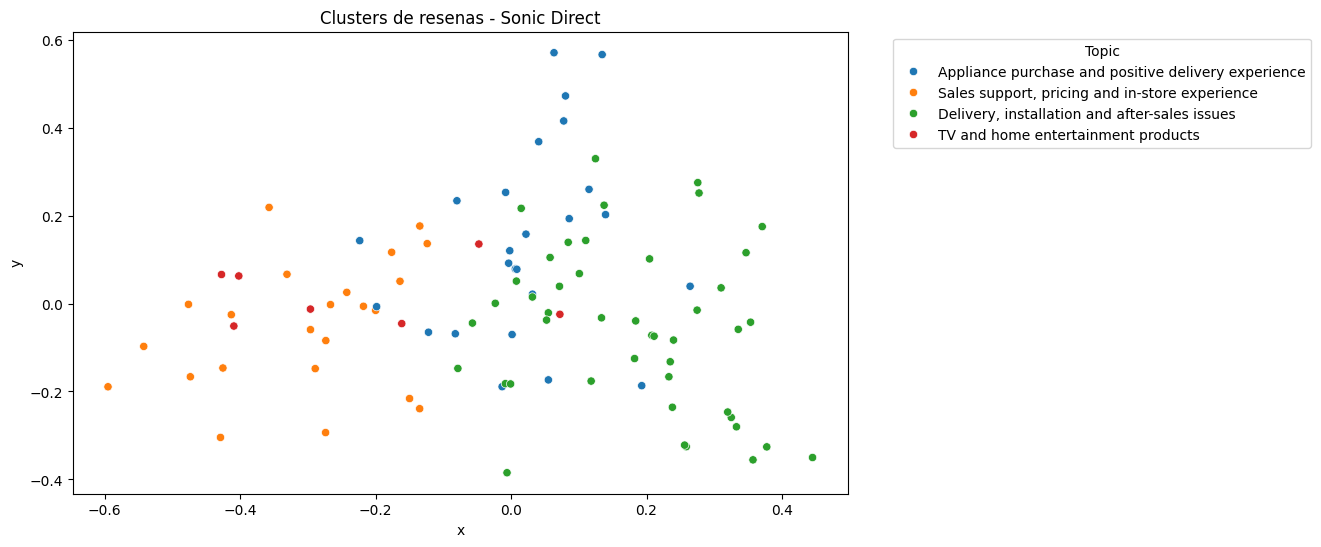

In [17]:
# Reducimos los embeddings a 2 dimensiones solo para poder visualizarlos.
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_empresa)

df_empresa["x"] = embeddings_2d[:, 0]
df_empresa["y"] = embeddings_2d[:, 1]

# Creamos una etiqueta legible para la grafica aunque el mapeo formal aparezca mas adelante.
mapa_topics_plot = {
    0: "TV and home entertainment products",
    1: "Delivery, installation and after-sales issues",
    2: "Appliance purchase and positive delivery experience",
    3: "Sales support, pricing and in-store experience"
}

df_empresa["topic_plot_name"] = df_empresa["topic"].map(mapa_topics_plot)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_empresa, x="x", y="y", hue="topic_plot_name", palette="tab10")
plt.title("Clusters de resenas - Sonic Direct")
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


## 6. Analisis de sentimiento

En esta fase clasificamos cada review como positiva o negativa.
Adem?s guardamos la confianza del modelo para poder usarla si m?s adelante queremos profundizar en casos dudosos.


In [18]:
# Cargamos un modelo preentrenado de analisis de sentimiento.
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2817.82it/s]


In [19]:
def analizar_sentimiento(textos, batch_size=32):
    # Procesamos en lotes para ganar eficiencia en colecciones grandes de reviews.
    resultados = sentiment_model(textos, batch_size=batch_size, truncation=True)
    labels = [r["label"] for r in resultados]
    scores = [r["score"] for r in resultados]
    return labels, scores


In [20]:
# Aplicamos el modelo a la empresa objetivo.
labels_emp, scores_emp = analizar_sentimiento(df_empresa["text"].tolist())

df_empresa["sentiment"] = labels_emp
df_empresa["sentiment_score"] = scores_emp


In [21]:
# Repetimos el mismo proceso para la competencia y asi poder comparar despues.
labels_comp, scores_comp = analizar_sentimiento(df_competencia["text"].tolist())

df_competencia["sentiment"] = labels_comp
df_competencia["sentiment_score"] = scores_comp


## 7. Comparacion global de sentimiento

Calculamos el porcentaje de reviews positivas y negativas en ambos grupos.
Este bloque responde a una pregunta clave: la empresa analizada genera mejores sensaciones que su competencia o peores.


In [22]:
# Calculamos distribuciones porcentuales de sentimiento para que la comparacion sea justa.
sent_empresa = df_empresa["sentiment"].value_counts(normalize=True).mul(100).round(2)
sent_comp = df_competencia["sentiment"].value_counts(normalize=True).mul(100).round(2)

comparacion_sent = pd.DataFrame({
    "Sonic Direct": sent_empresa,
    "Competencia": sent_comp
}).fillna(0)

comparacion_sent


,Sonic Direct,Competencia
sentiment,,
NEGATIVE,71.0,69.56
POSITIVE,29.0,30.44


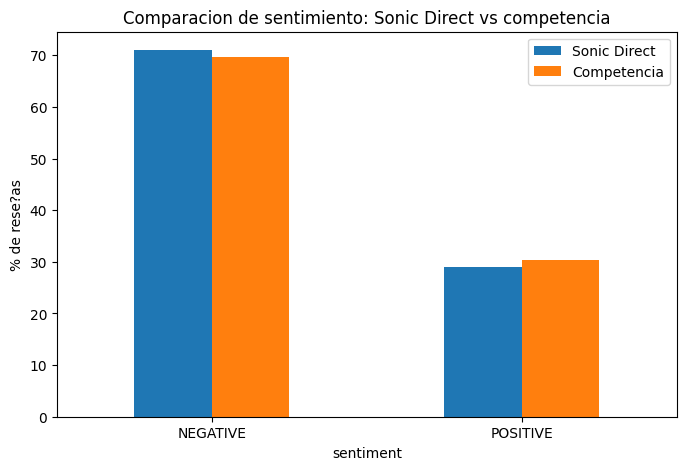

In [23]:
# Visualizamos la comparacion de forma mas intuitiva con un grafico de barras.
comparacion_sent.plot(kind="bar", figsize=(8, 5))
plt.title("Comparacion de sentimiento: Sonic Direct vs competencia")
plt.ylabel("% de rese?as")
plt.xticks(rotation=0)
plt.show()


> Nota de lectura de resultados:
>
> Este porcentaje de sentimiento refleja como clasifica el modelo el lenguaje de las reviews, no una tasa real de reputacion del negocio por si sola.
> Ademas, el modelo usado es binario (`POSITIVE` / `NEGATIVE`), asi que no contempla una clase neutra para resenas mixtas o tibias.


## 8. Temas en la competencia

Aplicamos el mismo flujo a la competencia para que la comparacion sea metodologicamente consistente.
Primero evaluamos varios valores de `k`, despues fijamos un numero de clusters interpretable y finalmente lo visualizamos con PCA.


In [24]:
# Generamos embeddings para las reviews de la competencia.
embeddings_competencia = model.encode(df_competencia["text"].tolist(), show_progress_bar=True)

# Evaluamos varios valores de k para tener una referencia cuantitativa antes de fijar el clustering final.
resultados_comp = []

for k in range(2, 11):
    kmeans_comp_eval = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_comp_eval = kmeans_comp_eval.fit_predict(embeddings_competencia)

    resultados_comp.append({
        "k": k,
        "inertia": kmeans_comp_eval.inertia_,
        "silhouette": silhouette_score(embeddings_competencia, labels_comp_eval),
        "calinski_harabasz": calinski_harabasz_score(embeddings_competencia, labels_comp_eval),
        "davies_bouldin": davies_bouldin_score(embeddings_competencia, labels_comp_eval)
    })

df_resultados_comp = pd.DataFrame(resultados_comp)
print(df_resultados_comp)

# Fijamos 5 clusters para la competencia porque permite una lectura mas rica del sector.
k_competencia = 5
kmeans_comp = KMeans(n_clusters=k_competencia, random_state=42, n_init=10)
df_competencia["topic"] = kmeans_comp.fit_predict(embeddings_competencia)


Batches:   0%|          | 0/172 [00:00<?, ?it/s]

Batches: 100%|██████████| 172/172 [00:43<00:00,  3.92it/s]


    k      inertia  silhouette  calinski_harabasz  davies_bouldin
0   2  4175.770020    0.033185         202.482219        5.152736
1   3  4073.125977    0.029957         172.986495        4.763806
2   4  3994.998047    0.026052         153.359453        4.632099
3   5  3933.222168    0.030768         138.365662        4.360644
4   6  3880.607422    0.030732         127.060112        4.222799
5   7  3840.254883    0.031975         116.589077        4.246550
6   8  3801.887451    0.027737         108.835764        4.138020
7   9  3769.946777    0.024132         101.831565        4.244282
8  10  3739.747070    0.024927          96.153716        4.140643


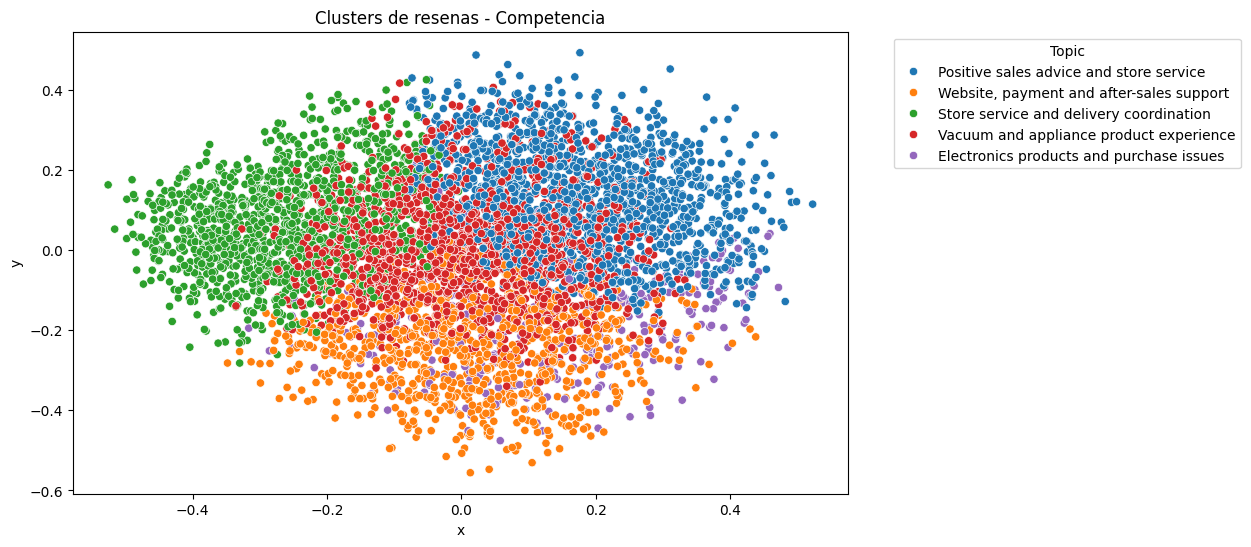

In [25]:
# Proyectamos los embeddings de la competencia en 2 dimensiones para visualizar los clusters.
pca_comp = PCA(n_components=2)
embeddings_comp_2d = pca_comp.fit_transform(embeddings_competencia)

df_competencia["x"] = embeddings_comp_2d[:, 0]
df_competencia["y"] = embeddings_comp_2d[:, 1]

mapa_topics_comp_plot = {
    0: "Electronics products and purchase issues",
    1: "Store service and delivery coordination",
    2: "Website, payment and after-sales support",
    3: "Positive sales advice and store service",
    4: "Vacuum and appliance product experience"
}

df_competencia["topic_plot_name"] = df_competencia["topic"].map(mapa_topics_comp_plot)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_competencia, x="x", y="y", hue="topic_plot_name", palette="tab10")
plt.title("Clusters de resenas - Competencia")
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


In [26]:
# Revisamos ejemplos de topics de la empresa en un formato legible.
for topic_id in sorted(df_empresa["topic"].unique()):
    print(f"\nTOPIC {topic_id}")
    topic_reviews = df_empresa[df_empresa["topic"] == topic_id]["review"]
    for review in topic_reviews:
        print("-", review)




TOPIC 0
- The sales person was well informed, however, a question to which the answer wasn't immediately available was researched through the excellent in store system to give the accurate response,  rather than the all too often, 'I think'.It was also amusing to be led through the first aisle of the tvs to the pay station...my wife had deliberately led me straight to the vacuums, studiously avoiding any contact with tvs! I appreciated being able to  browse them 'legitimately'
- Excellent Tv easy set up, great picture quality great price too, we already have a Samsung TV so we know how good they are.
- Very happy with the TV I have recently purchased. A member of staff was so helpful in explaining which TV would suit my needs as they all looked the same to me and I would probably have picked a much more expensive one. I would recommend this store if you want a good quality TV at a great price.
- The two men that delivered th television were pleasant and quick, however despite telling 

In [27]:
# Hacemos lo mismo con la competencia para interpretar sus clusters.
for topic_id in sorted(df_competencia["topic"].unique()):
    print(f"\nTOPIC {topic_id}")
    topic_reviews = df_competencia[df_competencia["topic"] == topic_id]["review"]
    for review in topic_reviews:
        print("-", review)




TOPIC 0
- The Shark Classic Upright Vacuum NV602UK is a fantastic choice! It’s well-known for its versatility and performance. Some of its standout features include:	•	DuoClean Technology: Combines two brush rolls for a seamless transition between carpets and hard floors.	•	Lift-Away Technology: Allows you to detach the pod for cleaning stairs, furniture, and hard-to-reach areas.	•	Anti-Allergen Complete Seal: Traps 99.9% of dust and allergens, making it ideal for allergy sufferers.	•	Lightweight and Easy to Maneuver: Despite being an upright vacuum, it’s designed for ease of use.
- Ordered a new cordless vacuum cleaner on Sunday, 29 Dec it arrived on Thursday, 2 Jan!! It came very well packed and it was very easy to put the cleaner together. Looking forward to using it!! The SharkNinja website is very easy to navigate and place an order. Definitely recommend Shark!!
- Don't buy any other hoover! It's amazing, I have dogs and the amount of dog hair, dust this hoover extracted from my 

In [28]:
# Guardamos las reviews de la competencia agrupadas por topic en un archivo de texto para su analisis posterior.
with open("data/topics_reviews_competencia.txt", "w", encoding="utf-8") as f:
    for topic_id in sorted(df_competencia["topic"].unique()):
        f.write(f"\n===== TOPIC {topic_id} =====\n")
        topic_reviews = df_competencia[df_competencia["topic"] == topic_id]["review"]
        for review in topic_reviews:
            f.write(f"- {review}\n")


In [29]:
print(df_competencia["topic"].value_counts().sort_index())

topic
0     385
1    1280
2     928
3    1451
4    1452
Name: count, dtype: int64


In [30]:
# Renombramos los clusters con etiquetas interpretables a partir de los ejemplos mostrados.
mapa_topics_empresa = {
    0: "TV and consumer electronics",
    1: "Delivery and post-purchase issues",
    2: "Positive appliance purchase experience",
    3: "Sales assistance and price perception"
}

df_empresa["topic_name"] = df_empresa["topic"].map(mapa_topics_empresa)

mapa_topics_comp = {
    0: "Vacuum product experience",
    1: "Store service and delivery",
    2: "Returns and after-sales support",
    3: "Positive sales support",
}

df_competencia["topic_name"] = df_competencia["topic"].map(mapa_topics_comp)


In [31]:
# Tabla resumen para ver claramente que nombre corresponde a cada cluster de la empresa.
pd.DataFrame(
    sorted(mapa_topics_empresa.items()),
    columns=["topic", "topic_name"]
)


,topic,topic_name
0,0,TV and consumer electronics
1,1,Delivery and post-purchase issues
2,2,Positive appliance purchase experience
3,3,Sales assistance and price perception


In [32]:
# Tabla resumen equivalente para la competencia.
pd.DataFrame(
    sorted(mapa_topics_comp.items()),
    columns=["topic", "topic_name"]
)


,topic,topic_name
0,0,Vacuum product experience
1,1,Store service and delivery
2,2,Returns and after-sales support
3,3,Positive sales support


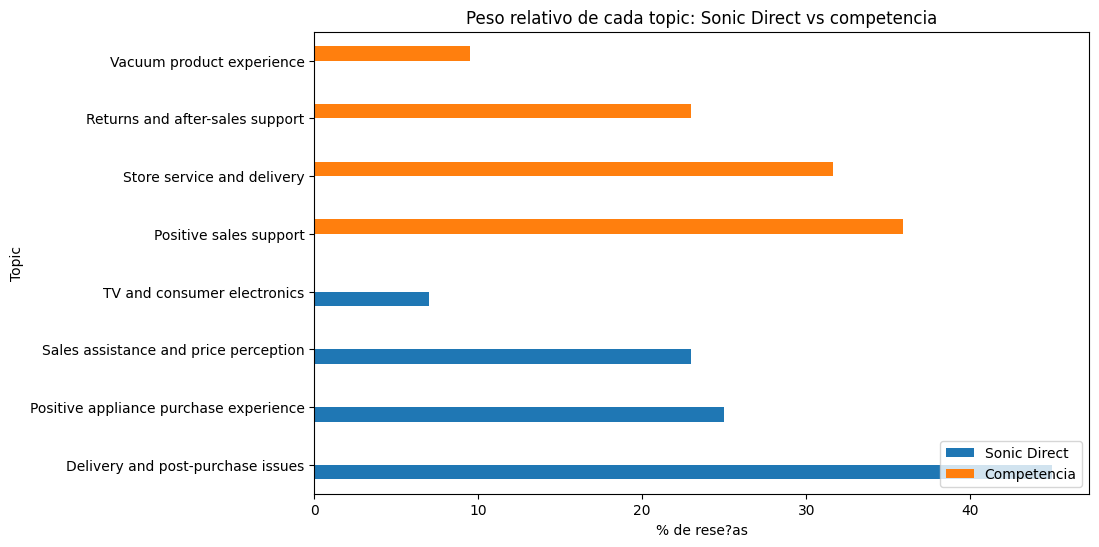

In [33]:
# Distribucion de reviews por topic para comparar el peso relativo de cada bloque tematico.
comparacion_topics = pd.concat([
    df_empresa["topic_name"].value_counts(normalize=True).mul(100).rename("Sonic Direct"),
    df_competencia["topic_name"].value_counts(normalize=True).mul(100).rename("Competencia")
], axis=1).fillna(0).round(2)

comparacion_topics

comparacion_topics.plot(kind="barh", figsize=(10, 6))
plt.title("Peso relativo de cada topic: Sonic Direct vs competencia")
plt.xlabel("% de rese?as")
plt.ylabel("Topic")
plt.legend(loc="lower right")
plt.show()


## 10. Sentimiento por topic

No solo importa el sentimiento global: tambi?n interesa saber en qu? temas aparecen m?s cr?ticas o m?s satisfacci?n.
Aqu? cruzamos topic y sentimiento para detectar puntos fuertes y puntos d?biles concretos.


In [34]:
# Calculamos la distribucion de sentimiento dentro de cada tema de la empresa.
sent_topic_empresa = (
    df_empresa.groupby(["topic_name", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

sent_topic_empresa_pct = sent_topic_empresa.div(sent_topic_empresa.sum(axis=1), axis=0) * 100
sent_topic_empresa_pct.round(2)


sentiment,NEGATIVE,POSITIVE
topic_name,,
Delivery and post-purchase issues,88.89,11.11
Positive appliance purchase experience,56.00,44.00
Sales assistance and price perception,47.83,52.17
TV and consumer electronics,85.71,14.29


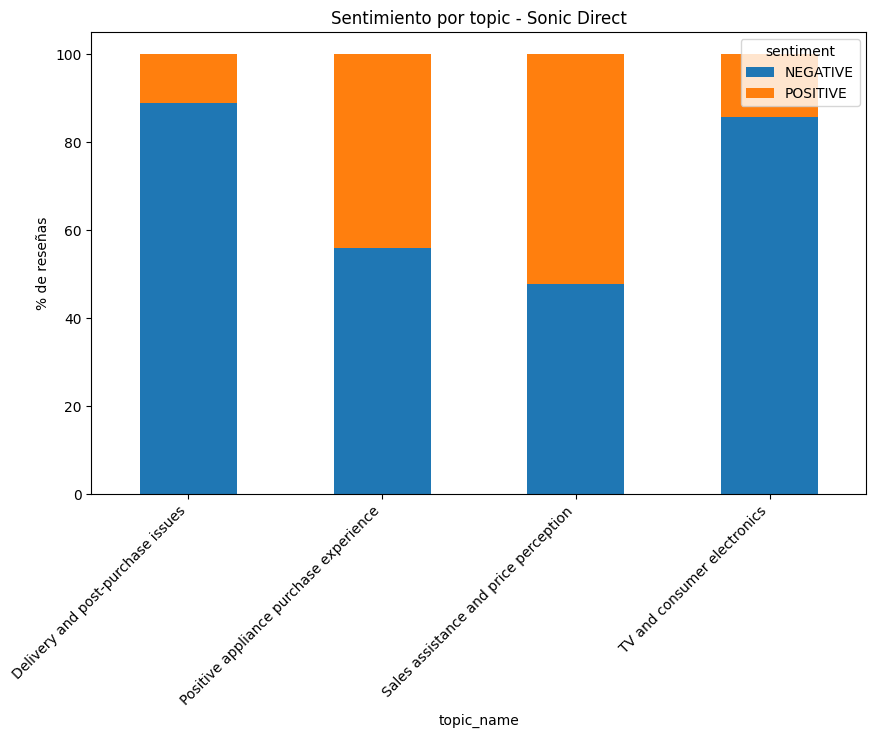

In [35]:
# Grafico apilado para ver de un vistazo que temas concentran mas opiniones negativas.
sent_topic_empresa_pct.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Sentimiento por topic - Sonic Direct")
plt.ylabel("% de reseñas")
plt.xticks(rotation=45, ha="right")
plt.show()


In [36]:
# Repetimos el analisis por topic para la competencia.
sent_topic_comp = (
    df_competencia.groupby(["topic_name", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

sent_topic_comp_pct = sent_topic_comp.div(sent_topic_comp.sum(axis=1), axis=0) * 100
sent_topic_comp_pct.round(2)


sentiment,NEGATIVE,POSITIVE
topic_name,,
Positive sales support,37.77,62.23
Returns and after-sales support,74.78,25.22
Store service and delivery,86.56,13.44
Vacuum product experience,74.55,25.45


## 11. Relacion entre sentimiento, topics y estrellas

Terminamos conectando el NLP con la valoraci?n num?rica en estrellas.
Esto ayuda a comprobar si los temas detectados y el sentimiento predicho tienen coherencia con la puntuaci?n que deja el cliente.


In [37]:
# Media de estrellas por sentimiento en la empresa.
df_empresa.groupby("sentiment")["stars"].mean()


sentiment
NEGATIVE    2.408451
POSITIVE    4.448276
Name: stars, dtype: float64

In [38]:
# Media de estrellas por sentimiento en la competencia.
df_competencia.groupby("sentiment")["stars"].mean()


sentiment
NEGATIVE    2.597960
POSITIVE    4.496712
Name: stars, dtype: float64

In [39]:
# Media de estrellas por topic en la empresa para detectar areas mejor y peor valoradas.
df_empresa.groupby("topic_name")["stars"].mean().sort_values()


topic_name
Delivery and post-purchase issues         2.488889
Positive appliance purchase experience    3.280000
TV and consumer electronics               3.428571
Sales assistance and price perception     3.565217
Name: stars, dtype: float64

In [40]:
# Media de estrellas por topic en la competencia.
df_competencia.groupby("topic_name")["stars"].mean().sort_values()


topic_name
Store service and delivery         2.653125
Vacuum product experience          3.067532
Returns and after-sales support    3.125000
Positive sales support             4.106134
Name: stars, dtype: float64

## 11.1 Lectura de negocio: fortalezas, debilidades y areas de mejora

Con las tablas de sentimiento por topic y estrellas medias por topic ya podemos responder de forma directa a las preguntas de negocio del caso.


In [41]:
# Sentimiento predominante por topic en empresa y competencia.
pred_empresa = sent_topic_empresa_pct.idxmax(axis=1).rename('predominant_sentiment_empresa')
pred_comp = sent_topic_comp_pct.idxmax(axis=1).rename('predominant_sentiment_competencia')

resumen_topics_empresa = pd.concat([
    sent_topic_empresa_pct.round(2),
    df_empresa.groupby('topic_name')['stars'].mean().round(2).rename('avg_stars')
], axis=1)
resumen_topics_empresa['predominant_sentiment'] = pred_empresa

resumen_topics_comp = pd.concat([
    sent_topic_comp_pct.round(2),
    df_competencia.groupby('topic_name')['stars'].mean().round(2).rename('avg_stars')
], axis=1)
resumen_topics_comp['predominant_sentiment'] = pred_comp

print('Resumen por topic - Sonic Direct')
display(resumen_topics_empresa.sort_values('avg_stars'))

print('Resumen por topic - Competencia')
display(resumen_topics_comp.sort_values('avg_stars'))


Resumen por topic - Sonic Direct


,NEGATIVE,POSITIVE,avg_stars,predominant_sentiment
topic_name,,,,
Delivery and post-purchase issues,88.89,11.11,2.49,NEGATIVE
Positive appliance purchase experience,56.00,44.00,3.28,NEGATIVE
TV and consumer electronics,85.71,14.29,3.43,NEGATIVE
Sales assistance and price perception,47.83,52.17,3.57,POSITIVE


Resumen por topic - Competencia


,NEGATIVE,POSITIVE,avg_stars,predominant_sentiment
topic_name,,,,
Store service and delivery,86.56,13.44,2.65,NEGATIVE
Vacuum product experience,74.55,25.45,3.07,NEGATIVE
Returns and after-sales support,74.78,25.22,3.12,NEGATIVE
Positive sales support,37.77,62.23,4.11,POSITIVE


### Respuesta directa a las preguntas del caso

- En Sonic Direct, el sentimiento predominante es claramente negativo en `Delivery and post-purchase issues` y en `TV and consumer electronics`. El bloque mas favorable es `Sales assistance and price perception`, que es el unico donde domina ligeramente el sentimiento positivo.
- En la competencia, tambien aparece un foco claramente positivo en `Positive sales advice and store service`, mientras que los bloques mas problematicos se concentran en `Store service and delivery coordination`, `Vacuum products, quality and warranty issues`, `Product faults, returns and after-sales care` y `Website, ordering and fulfilment issues`.
- Donde Sonic Direct parece relativamente mejor es en la atencion comercial y la experiencia de venta, porque su topic `Sales assistance and price perception` mantiene una mezcla algo mas favorable y una media de estrellas competitiva.
- Donde Sonic Direct parece peor es en entrega, instalacion y postcompra, ya que `Delivery and post-purchase issues` es su bloque con peor combinacion de sentimiento y una de las medias de estrellas mas bajas del analisis.
- La comparacion con la competencia sugiere que el dolor principal no esta solo en el producto, sino en la operativa de entrega, la instalacion y la resolucion posterior de incidencias.
- Las principales areas de mejora para Sonic Direct son: reducir fallos de entrega y retrasos, mejorar la calidad de la instalacion/retirada, reforzar la coordinacion con transportistas y profesionalizar la atencion postventa cuando hay da?os, devoluciones o problemas tecnicos.


## 12. Exploracion lexica con WordCloud

Estas visualizaciones sirven para detectar palabras muy repetidas en las reviews de la empresa.
Son utiles como apoyo visual, aunque no sustituyen al analisis de sentimiento ni al modelado de topics.


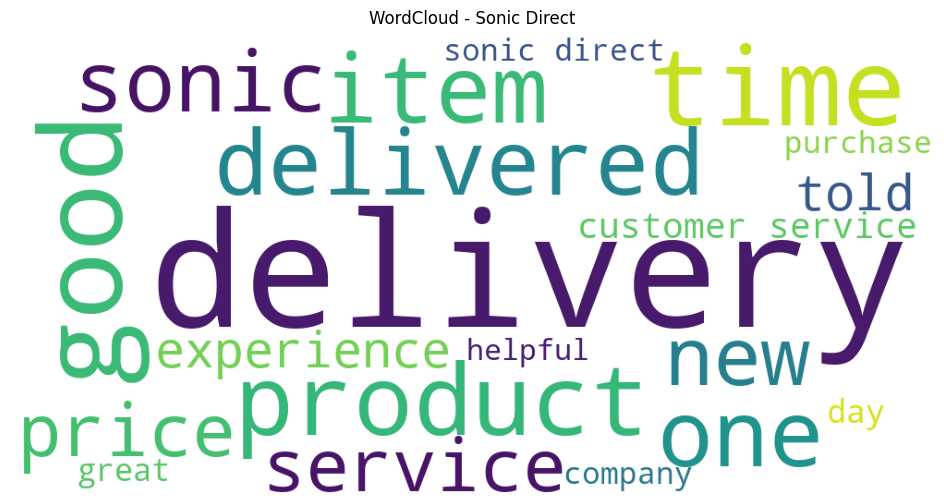

In [42]:
# Nube de palabras global de Sonic Direct.
texto_empresa = " ".join(df_empresa["text"])

wc = WordCloud(width=1000, height=500, background_color="white", max_words=20).generate(texto_empresa)

plt.figure(figsize=(12, 6))
plt.imshow(wc)
plt.axis("off")
plt.title("WordCloud - Sonic Direct")
plt.show()


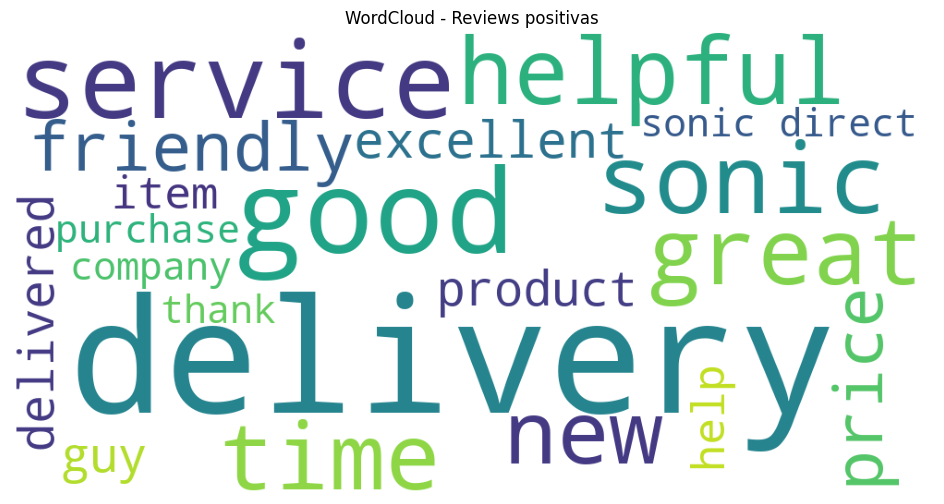

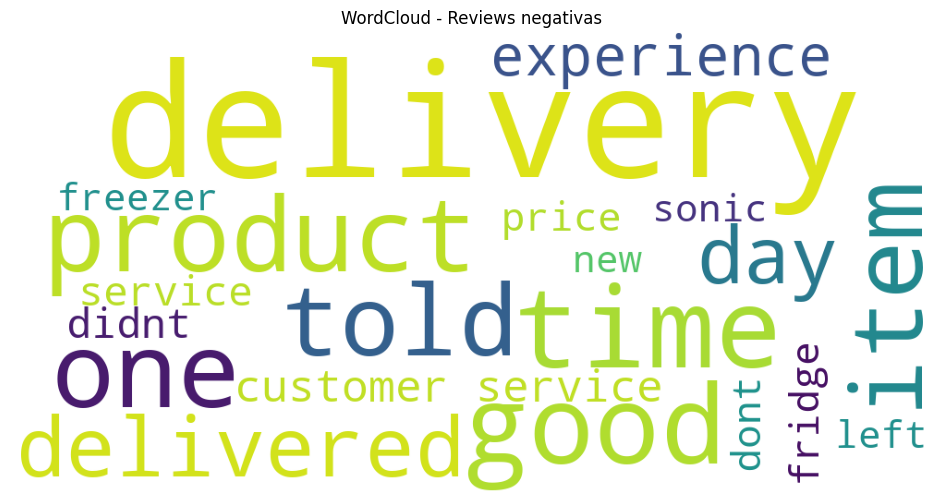

In [43]:
# Separamos el vocabulario de reviews positivas y negativas para comparar tonos y focos.
texto_pos = " ".join(df_empresa[df_empresa["sentiment"] == "POSITIVE"]["text"])
texto_neg = " ".join(df_empresa[df_empresa["sentiment"] == "NEGATIVE"]["text"])

wc_pos = WordCloud(width=1000, height=500, background_color="white", max_words=20).generate(texto_pos)
wc_neg = WordCloud(width=1000, height=500, background_color="white", max_words=20).generate(texto_neg)

plt.figure(figsize=(12, 6))
plt.imshow(wc_pos)
plt.axis("off")
plt.title("WordCloud - Reviews positivas")
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(wc_neg)
plt.axis("off")
plt.title("WordCloud - Reviews negativas")
plt.show()


## 13. Analisis alternativo con BERTopic

Despues del enfoque basado en embeddings + KMeans, aqui probamos un modelado de topics mas avanzado con BERTopic.
La idea no es sustituir automaticamente al bloque anterior, sino usarlo como contraste para ver si aparecen temas parecidos o mas interpretable.


In [44]:
# Eliminamos stopwords para ayudar a BERTopic a centrarse en palabras con mas contenido semantico.
stopwords = set(ENGLISH_STOP_WORDS)

def limpiar_texto_topics(texto):
    if not isinstance(texto, str):
        return ""
    
    texto = texto.lower()
    texto = re.sub(r'http\S+|www\.\S+', ' ', texto)      # URLs
    texto = re.sub(r'[^\x00-\x7F]+', ' ', texto)         # no ASCII / emojis
    texto = re.sub(r'#(\w+)', r'\1', texto)              # conservar palabra del hashtag
    texto = re.sub(r'\d+', ' ', texto)                   # números
    texto = re.sub(r'[^\w\s]', ' ', texto)               # puntuación
    texto = re.sub(r'_', ' ', texto)                     # guiones bajos
    texto = re.sub(r'\s+', ' ', texto).strip()           # espacios extra
    
    palabras = texto.split()
    palabras = [w for w in palabras if w not in stopwords and len(w) > 2]
    
    return " ".join(palabras)

df_empresa["text_topics"] = df_empresa["text"].apply(limpiar_texto_topics)


In [45]:
# Entrenamos BERTopic solo con las reviews de la empresa.
# Esto nos da topics mas flexibles, incluyendo un topic -1 para outliers o textos menos agrupables.
topic_model_emp = BERTopic(language="english", calculate_probabilities=True, verbose=True)
topics_emp, probs_emp = topic_model_emp.fit_transform(df_empresa["text_topics"].tolist())

df_empresa["bertopic_topic"] = topics_emp


2026-04-15 17:12:47,958 - BERTopic - Embedding - Transforming documents to embeddings.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2262.98it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 4/4 [00:00<00:00,  5.74it/s]
2026-04-15 17:12:52,143 - BERTopic - Embedding - Completed ✓
2026-04-15 17:12:52,144 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-15 17:13:10,200 - BERTopic - Dimensionality - Completed ✓
2026-04-15 17:13:10,201 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-15 17:13:10,231 - BERTopic - Cluster - Completed ✓
2026-04-15 17:13:10,237 - BERTopic - Representation - Fine-tuning topics using representation mode

In [46]:
# Resumen de topics detectados: tamano, nombre automatico y documentos representativos.
topic_model_emp.get_topic_info()


,Topic,Count,Name,Representation,Representative_Docs
0,-1,19,-1_delivery_deliver_told_email,"[delivery, deliver, told, email, item, product, service, delivered, sales, customer]","[delivery montpellier combi microwave oven service good speedyhowever delivery company used left lot desiredthey did deliver correct date delivered wrong address gall say delivered mei suggest contact company change practices fortunate didnt lose appliance resulting delivery claim require proof apc delivery email send thankyou tony covachich, unless need return item unfortunately window cleaner product received used returned item security seal broken looked like used customer services polite phone asked email photo proof wanted return refund email reply advised email return label collection wait day collection leave parcel company collect school runs special needs child theres way think day age able email label send code crazy wont using company, disappointed occasion poor delivery commitmentsst delivery agreed point sale contacted evening informed fridgefreezer unit delivered availablend delivery days later unit delivered damagedrd attempt early morning delivery aborted told delivery van broken downhad wait day available known late afternoon unit delivered bought initial delivery booked final resolution early eveningthe delivery people good took great care ensure expected salesman informed product received excellent service previous purchases reason returned sonic purchase]"
1,0,58,0_delivery_service_time_good,"[delivery, service, time, good, machine, experience, guys, customer, new, ordered]","[good experience moment looked website extensive choice knew looking did plenty information products help making purchase pleased delivery date quicker expected christmasnew year delivery men extremely courteous approachable explained needed know appliance position took away packaging leaving lovely new fridgefreezer delivery window excellent time good experience guys delivered jas aasim thank, delivery installation issues experience store good salesman friendly knowledgeable buying process faultless extremely disappointed way treated delivery men paid new washer installed guys insisted washer brought ordered wasnt case black hadnt looked black ones store eventually backed checked van realised mistake said wasnt job remove old machine install new paperwork showing paid services muttered constantly saying salesman right make promises reluctantly agreed rushed hurry job reading washing machine manual retaining bolts left future use spanner taken away unpleasant upsetting experience, time using company wont time referring friends family time using company wont time place appliance quality customer service start finish ordered american fridge freezer ordering got asking check measurements doors gates access delivery day delivery best delivery guys help care sandeep zulfi sure got massive fridge freezer ally way steps kitchen treating delivery care precision recommending family friends use company]"
2,1,23,1_sonic_direct_product_price,"[sonic, direct, product, price, great, purchased, service, good, said, products]","[great price fantastic delivery purchased tumble drier christmas period sonic direct best price drier wanted accounting delivery extras installation removal old drier drier delivered quickly delivery guys kasam faisal fantastic communicated arrive friendly explained installation new drier process extremely quick pain free definitely use sonic direct, bought appliances sonic bought appliances sonic new kitchen helped riz absolutely fantastic regards helping right product providing really positive customer experience riz sure getting best deals buying quality products explained guarantees sent links register trouble given stars washer broken foot taken delivery team ringing riz sorted newer model ready collect day sonic sell lower prices store really happy service price range quality thanks riz help, excellent service provided sonic direct service provi

In [47]:
# Palabras mas representativas del topic 0.
topic_model_emp.get_topic(0)


[('delivery', np.float64(0.09624618058009089)),
 ('service', np.float64(0.04707806721282967)),
 ('time', np.float64(0.041942513861903216)),
 ('good', np.float64(0.0412728485489303)),
 ('machine', np.float64(0.03870924927680448)),
 ('experience', np.float64(0.03727537424853525)),
 ('guys', np.float64(0.0335366860553828)),
 ('customer', np.float64(0.032382947736915364)),
 ('new', np.float64(0.03106281187377937)),
 ('ordered', np.float64(0.029650597885223385))]

In [48]:
# Grafico de barras con las palabras mas importantes por topic.
topic_model_emp.visualize_barchart()


In [49]:
# Jerarquia entre topics para ver si algunos grupos podrian fusionarse conceptualmente.
topic_model_emp.visualize_hierarchy()


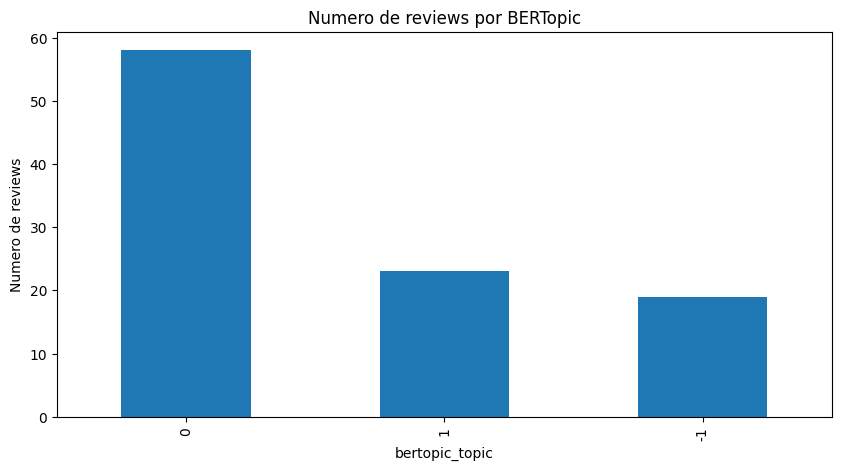

In [50]:
# Vemos cuantos documentos han caido en cada topic y lo representamos en un grafico.
df_empresa["bertopic_topic"].value_counts().sort_index()

df_empresa["bertopic_topic"].value_counts().sort_values(ascending=False).plot(
    kind="bar", figsize=(10, 5), title="Numero de reviews por BERTopic"
)
plt.ylabel("Numero de reviews")
plt.show()


In [51]:
# Cruzamos los topics de BERTopic con el sentimiento para detectar temas mas positivos o mas negativos.
bertopic_sent = (
    df_empresa.groupby(["bertopic_topic", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

bertopic_sent


sentiment,NEGATIVE,POSITIVE
bertopic_topic,,
-1,18,1
0,43,15
1,10,13


In [52]:
# Pasamos los conteos a porcentaje para poder comparar topics con distinto volumen.
bertopic_sent_pct = bertopic_sent.div(bertopic_sent.sum(axis=1), axis=0) * 100
bertopic_sent_pct.round(2)


sentiment,NEGATIVE,POSITIVE
bertopic_topic,,
-1,94.74,5.26
0,74.14,25.86
1,43.48,56.52


### 13.2 Renombrado de topics de BERTopic

Una vez inspeccionadas las palabras clave y ejemplos reales, podemos traducir los IDs de BERTopic a etiquetas de negocio.
Esto hace mucho mas facil leer tablas, ejemplos y conclusiones sin depender de numeros abstractos.


In [53]:
# Etiquetas sugeridas a partir de las palabras clave y los ejemplos de cada topic.
mapa_bertopic_empresa = {
    -1: "Mixed or less consistent reviews",
    0: "Delivery, installation and service incidents",
    1: "Sales attention and product purchase experience",
    2: "Positive purchase, delivery and staff support"
}

df_empresa["bertopic_name"] = df_empresa["bertopic_topic"].map(mapa_bertopic_empresa)

df_empresa[["bertopic_topic", "bertopic_name"]].drop_duplicates().sort_values("bertopic_topic")


,bertopic_topic,bertopic_name
4,-1,Mixed or less consistent reviews
0,0,"Delivery, installation and service incidents"
1,1,Sales attention and product purchase experience


In [54]:
df_empresa["bertopic_topic"].value_counts().sort_index()


bertopic_topic
-1    19
 0    58
 1    23
Name: count, dtype: int64

In [55]:
df_empresa["bertopic_topic"].unique()

array([ 0,  1, -1])

In [56]:
df_empresa[df_empresa["bertopic_topic"] == 2][["text", "sentiment"]].head(10)

,text,sentiment


In [57]:
# Rehacemos la tabla de sentimiento usando los nombres de topic en lugar de los IDs numericos.
bertopic_sent_named = (
    df_empresa.groupby(["bertopic_topic","bertopic_name", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

bertopic_sent_named_pct = bertopic_sent_named.div(bertopic_sent_named.sum(axis=1), axis=0) * 100
bertopic_sent_named_pct.round(2)


,sentiment,NEGATIVE,POSITIVE
bertopic_topic,bertopic_name,,
-1,Mixed or less consistent reviews,94.74,5.26
0,"Delivery, installation and service incidents",74.14,25.86
1,Sales attention and product purchase experience,43.48,56.52


In [58]:
pd.set_option('display.max_colwidth', None)

df_empresa[df_empresa["sentiment"] == "NEGATIVE"][[
    "review_id", "title", "review", "text"
]]

,review_id,title,review,text
3,3,Our washing machine,Our washing machine broke down two days before Christmas. We did a price check from a number of suppliers for a new machine. Sonic was the most attractive. Ordered on line. The sales manager contacted me to confirm the order and informed me that I would receive a e mail that evening to inform us what time it would be delivered and in stalled the following day. The driver rang 30 mins before the scheduled time. Arrived installed and up and running within 24 hours from ordering. Brilliant service.,our washing machine our washing machine broke down two days before christmas we did a price check from a number of suppliers for a new machine sonic was the most attractive ordered on line the sales manager contacted me to confirm the order and informed me that i would receive a e mail that evening to inform us what time it would be delivered and in stalled the following day the driver rang mins before the scheduled time arrived installed and up and running within hours from ordering brilliant service
4,4,"Well informed sales person, resulted in our purchasing a 'variation' to what we expected to buy.","The sales person was well informed, however, a question to which the answer wasn't immediately available was researched through the excellent in store system to give the accurate response, rather than the all too often, 'I think'.It was also amusing to be led through the first aisle of the tvs to the pay station...my wife had deliberately led me straight to the vacuums, studiously avoiding any contact with tvs! I appreciated being able to browse them 'legitimately'",well informed sales person resulted in our purchasing a variation to what we expected to buy the sales person was well informed however a question to which the answer wasnt immediately available was researched through the excellent in store system to give the accurate response rather than the all too often i thinkit was also amusing to be led through the first aisle of the tvs to the pay stationmy wife had deliberately led me straight to the vacuums studiously avoiding any contact with tvs i appreciated being able to browse them legitimately
6,6,Lots of choice online and although i…,"Lots of choice online and although i was on the last minute still received the fridge/freezer in plenty time for getting a christmas shop in. The only problem was it is a bit too small but that was my own fault because i didn't check the size. Delivery guys was brilliant and kept in touch regarding time, would use Sonic direct again.",lots of choice online and although i lots of choice online and although i was on the last minute still received the fridgefreezer in plenty time for getting a christmas shop in the only problem was it is a bit too small but that was my own fault because i didnt check the size delivery guys was brilliant and kept in touch regarding time would use sonic direct again
22,22,"I had problems, but they were all resolved.","The website picture was misleading, and on delivery I was able to speak to the sales staff who agreed and the delivery was cancelled - all very efficiently. The delivery guys were polite and understanding. A delivery was then missed (friday evening!) and it did feel like someone had made up a story about trying to deliver, calling and putting something through my letterbox - as I had no calls, and have security cameras that would have picked them up (I was watching as I was waiting for the delivery). However, it was delivered a few days later and again the delivery staff were really polite and understanding. So there were a few issues, but it was all sorted effectively and efficiently. If it wasn't for the Friday night mess up, it would have been 5 stars.",i had problems but they were all resolved the website picture was misleading and on delivery i was able to speak to the sales staff who agreed and the delivery was cancelled all very efficiently the delivery guys were polite and understanding a deli

### 13.1 Lectura de los topics de BERTopic

En las siguientes celdas inspeccionamos palabras clave y ejemplos reales de reviews dentro de cada topic.
Esto ayuda a decidir si BERTopic esta separando mejor los temas de negocio que KMeans o si ambos cuentan una historia parecida.


In [59]:
# Comparamos las palabras mas representativas de los topics principales.
display(topic_model_emp.get_topic(0))
print("\n" + "="*50 + "\n")
topic_model_emp.get_topic(1)


[('delivery', np.float64(0.09624618058009089)),
 ('service', np.float64(0.04707806721282967)),
 ('time', np.float64(0.041942513861903216)),
 ('good', np.float64(0.0412728485489303)),
 ('machine', np.float64(0.03870924927680448)),
 ('experience', np.float64(0.03727537424853525)),
 ('guys', np.float64(0.0335366860553828)),
 ('customer', np.float64(0.032382947736915364)),
 ('new', np.float64(0.03106281187377937)),
 ('ordered', np.float64(0.029650597885223385))]

[('sonic', np.float64(0.14487845696413928)),
 ('direct', np.float64(0.08073254510374298)),
 ('product', np.float64(0.06341923054380567)),
 ('price', np.float64(0.06210195777210998)),
 ('great', np.float64(0.06210195777210998)),
 ('purchased', np.float64(0.050067154979399786)),
 ('service', np.float64(0.047894799584694996)),
 ('good', np.float64(0.04600519589249124)),
 ('said', np.float64(0.04547952391575032)),
 ('products', np.float64(0.043965747498657996))]

In [60]:
# Ejemplos reales del topic 0 para validar su interpretacion.
df_empresa[df_empresa["bertopic_topic"] == 0].columns


Index(['category', 'company', 'description', 'title', 'review', 'stars',
       'review_id', 'text', 'topic', 'x', 'y', 'topic_plot_name', 'sentiment',
       'sentiment_score', 'topic_name', 'text_topics', 'bertopic_topic',
       'bertopic_name'],
      dtype='str')

In [61]:
# Ejemplos reales del topic 1 para validar su interpretacion.
df_empresa[df_empresa["bertopic_topic"] == 1][["text", "sentiment"]].head(10)


,text,sentiment
1,great price fantastic delivery we purchased a tumble drier over the christmas period sonic direct had the best price for the drier we wanted after accounting for delivery and extras installation and removal of old drier the drier was delivered very quickly and the delivery guys kasam and faisal were fantastic communicated when they would arrive and were very friendly they explained everything during the installation of the new drier and the whole process was extremely quick and pain free would definitely use sonic direct again,POSITIVE
8,great product excellent tv easy set up great picture quality great price too we already have a samsung tv so we know how good they are,POSITIVE
10,excellent service provided by sonic direct the service that was provided by sonic direct was excellent both in the store whilst ordering and paying for my purchase and afterwards when my purchase was delivered by van to my house i would particularly like to thank the delivery van crew who were very helpful and friendly the delivery van crew were called mindy and maciey and i would like to thank them for their excellent service whilst delivering my purchase and collecting my old appliance which was due to be taken away for recycling the delivery took place within the scheduled time frame and i was provided with useful updates and information about the delivery via text messages and a phone call prior to the delivery thank you mindy and maciey for your excellent service it was much appreciated,POSITIVE
11,amazing service everyone in sonic direct is welcoming and friendly they dont pester you but at the same time are there to help if you do need them i have bought a few things from here and had amazing customer service every time,POSITIVE
14,helpful and efficient our old tumbler stopped working on saturday i rang sonic and they were very helpful they delivered a new one the next day sunday even though it was only days before xmas they were very efficient and friendly and carried away the old tumbledryer and brought the new one in the utility,POSITIVE
15,sonic direct review salesman sqs was very knowledgeable of products and very helpfulsale was done efficiently and quickly ands a delivery date for next day was agreedwas delivered next day as promised all good,POSITIVE
17,always helpful friendly and always helpful friendly and knowledgeable staff we are mostly served by cash who goes above and beyond assistance wouldnt go anywhere else than sonic for our electrical needs,POSITIVE
20,sonic were great sonic were great parcel force the delivery company were not the item when it finally arrived is very good the person for whom it was purchased is very pleased with it,POSITIVE
21,simple and effective i was very pleased that sonic were able to price match with another offer the customer service representative tood the details and called me back with an update the pick up was simple and without hassle,POSITIVE
29,i bought appliances from sonic for my i bought appliances from sonic for my new kitchen i was helped by riz who is absolutely fantastic with regards to helping to find the right product for you and providing a really positive customer experience riz made sure i was getting the best deals and was buying quality products he explained the guarantees and sent links to register nothing was too much trouble i would have given stars but the washer had a broken foot so was taken back by the delivery team on ringing riz he sorted out the newer model for me and it was ready to collect the next day for us sonic sell at lower prices if you go in store and i was really happy with the service price range and quality thanks riz for all your help,POSITIVE


In [62]:
# Ejemplos del topic -1, que BERTopic suele usar para outliers o textos menos homogeneos.
df_empresa[df_empresa["bertopic_topic"] == -1][["text", "sentiment"]].head(10)


,text,sentiment
4,well informed sales person resulted in our purchasing a variation to what we expected to buy the sales person was well informed however a question to which the answer wasnt immediately available was researched through the excellent in store system to give the accurate response rather than the all too often i thinkit was also amusing to be led through the first aisle of the tvs to the pay stationmy wife had deliberately led me straight to the vacuums studiously avoiding any contact with tvs i appreciated being able to browse them legitimately,NEGATIVE
6,lots of choice online and although i lots of choice online and although i was on the last minute still received the fridgefreezer in plenty time for getting a christmas shop in the only problem was it is a bit too small but that was my own fault because i didnt check the size delivery guys was brilliant and kept in touch regarding time would use sonic direct again,NEGATIVE
19,we spoke with staff members who clearly outlined the pros and cons of the items we were looking at this meant that we were able to leave with an item which we found best suited our needs and having installed it we are very pleased with it,POSITIVE
28,love my new range cooker and cooker love my new range cooker and cooker hood the delivery people didnt manage to get it into my kitchen which would have been helpful,NEGATIVE
36,very quick responsepositive experience very quick response to my order for a small fridge freezer delivery guys fine although hadnt read where to enter my property so far im pleased with my haden purchase although its not as roomy as my old lec fridge freezer but choice was extremely limited thank you sonic direct for stocking these smaller ones,NEGATIVE
38,delivery of my montpellier combi microwave oven your service was very good and speedyhowever the delivery company that you used left a lot to be desiredthey did deliver on the correct date however they delivered to the wrong address and had the gall to say that it had been delivered to mei suggest that you contact this company and get them to change their practices as it is very fortunate that we didnt lose our appliance resulting in a no delivery claim if you require proof i have the apc delivery email i can send you thankyou tony covachich,NEGATIVE
42,quick delivery shame the box was damaged easy to order on line and delivered in a few daysthe mixer was only packed in a plastic bag and the corner of the box was damaged which isnt great as it is a christmas gift,NEGATIVE
47,your assistants did not seem interested your assistants did not seem interested in serving us and continued to put pricing labels of their goods goods brought from a back warehouse even though they were piled high on the shop floor,NEGATIVE
49,good product basic packaging ie a bag no invoice sent on dispatch and a day late box and bag terribly damaged but product survived and works sonic is okay but they may aim to deliver on date but the courier may not get there parcelforce are not gentle on freight ive worked for most courier companies,NEGATIVE
53,would have given stars arrogant woman at customer sales desk would have given stars but for the arrogant rude middle age woman employed on the customer service counter another customer has complained about her on this review siteand i met her and now understand no customer service skills whatsoever i stood at the customer service counter till she deigned to acknowledge meand she spoke to me as if i was a nuisance to be delt withtheir prices are not cheaper than any other online electronics retailer so next time i will use one of their competitors,NEGATIVE


## 14. Conclusiones y validacion de outputs

Lo que muestran las salidas del notebook encaja con el objetivo del proyecto, pero con varios matices importantes:

- El flujo general ahora si sigue una narrativa consistente: datos, empresa, competencia, limpieza, topics, sentimiento, comparacion, exploracion adicional y cierre.
- La comparacion global de sentimiento es internamente coherente con el resto del notebook, pero debe interpretarse como polaridad del lenguaje y no como reputacion real agregada.
- Las medias de estrellas por sentimiento cuadran con esa lectura: las reviews clasificadas como `POSITIVE` tienen mas estrellas que las `NEGATIVE` tanto en la empresa como en la competencia.
- El analisis de topics con `KMeans` ya esta alineado entre empresa y competencia: en ambos casos se generan embeddings, se revisan metricas para `k`, se clusteriza, se inspeccionan ejemplos reales y se visualiza la estructura con PCA.
- En Sonic Direct, los bloques mas sensibles parecen concentrarse en `Delivery and post-purchase issues`, mientras que los clusters positivos se mueven mas alrededor de producto, compra e interaccion comercial.
- En la competencia, el modelado tematico ayuda a separar mejor varios focos del sector, como tienda, soporte web/postventa y experiencias de producto.
- Aun asi, algunos clusters de `KMeans` siguen siendo mixtos, asi que conviene validar siempre las etiquetas leyendo ejemplos reales antes de cerrar una conclusion de negocio.
- `BERTopic` sigue siendo un buen contraste exploratorio, pero el flujo principal del notebook queda suficientemente consistente con `embeddings + KMeans + sentimiento`.

Siguiente uso recomendado del notebook:
- usar KMeans para una lectura ejecutiva rapida
- usar BERTopic como contraste exploratorio
- cerrar con una celda final de insights de negocio y areas de mejora accionables
